# **Project Name - Fake News Detector**    



##### **Project Type**    - NLP
##### **Contribution**    - Individual
##### **Team Member  - Kartik Dalal**


# **Project Summary -**

This project focuses on building a machine learning-based system to classify news articles as True (0) or Fake (1) using Natural Language Processing (NLP) techniques.

The dataset consists of textual news data, which was preprocessed through multiple stages including tokenization, text normalization (lemmatization), stopword removal, and cleaning to improve data quality. The processed text was then converted into numerical form using the TF-IDF (Term Frequency–Inverse Document Frequency) vectorization technique, which captures the importance of words while reducing the impact of common terms.

To ensure proper model evaluation and avoid data leakage, the dataset was split into training and testing sets before applying vectorization.

Multiple machine learning models were implemented, including Naive Bayes, Logistic Regression, and Support Vector Machine (SVM). These models were trained on the processed data and evaluated using metrics such as accuracy, precision, recall, and F1-score. A comparative analysis was performed to identify the best-performing model.

The system also includes a real-time prediction pipeline where user input is preprocessed using the same steps (tokenization and lemmatization), transformed using the trained TF-IDF vectorizer, and then passed to the trained model for classification.

Overall, this project demonstrates the complete NLP pipeline, from data preprocessing and feature engineering to model training, evaluation, and deployment-ready prediction, providing an effective solution for detecting fake news.

# **Problem Statement**


The project aims to build an automated system using NLP and machine learning to classify news articles as real or fake. It addresses the challenge of detecting misinformation at scale by analyzing textual patterns and improving reliability in news consumption.

The project aims to build an automated system using NLP and machine learning to classify news articles as real or fake. It addresses the challenge of detecting misinformation at scale by analyzing textual patterns and improving reliability in news consumption.

# ***Let's Begin !***

## ***1. Know Your Data***

### **Import Libraries**

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Dataset Loading**

In [ ]:
# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
true = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA_SETS/True.csv')
fake = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA_SETS/Fake.csv')

### **Dataset First View**

In [ ]:
# Dataset First Look

In [ ]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


### **Dataset Rows & Columns count**

In [ ]:
# Dataset Rows & Columns count

In [ ]:
true.shape

(21417, 4)

In [ ]:
fake.shape

(23481, 4)

### **Dataset Information**

In [ ]:
# Dataset Info

In [ ]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [ ]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


### **Duplicate Values**

In [ ]:
# Dataset Duplicate Value Count

In [ ]:
true.duplicated().sum()

np.int64(206)

In [ ]:
fake.duplicated().sum()

np.int64(3)

### **Missing Values/Null Values**

In [ ]:
# Missing Values/Null Values Count

In [ ]:
true.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [ ]:
fake.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [ ]:
# Visualizing the missing values

## ***2. Understanding Your Variables***

### **Dataset Columns**

In [ ]:
# Dataset Columns

In [ ]:
true.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [ ]:
fake.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [ ]:
# Dataset Describe

### **Variables Description**

In [ ]:
true.describe()

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [ ]:
fake.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


### **Check Unique Values for each variable.**

In [ ]:
# Check Unique Values for each variable.

In [ ]:
true.nunique()

,0
title,20826
text,21192
subject,2
date,716


In [ ]:
fake.nunique()

,0
title,17903
text,17455
subject,6
date,1681


## ***3. Data Wrangling***

In [ ]:
# Writing code to make dataset analysis ready.

### **Handling duplicate values**

In [ ]:
true.shape , true.duplicated().sum()

((21417, 4), np.int64(206))

In [ ]:
true.drop_duplicates(inplace=True)

In [ ]:
true.shape , true.duplicated().sum()

((21211, 4), np.int64(0))

In [ ]:
fake.shape , fake.duplicated().sum()

((23481, 4), np.int64(3))

In [ ]:
true.drop_duplicates(inplace=True)

In [ ]:
fake.shape , fake.duplicated().sum()

((23481, 4), np.int64(3))

### **Adding columns in dataset**

####**Adding a column "Result" in both datasets as it is the output.**

In [ ]:
true['Result'] = 0

In [ ]:
print(true['Result'].value_counts())

Result
0    21211
Name: count, dtype: int64


In [ ]:
true.head()

,title,text,subject,date,Result
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [ ]:
fake['Result'] = 1

In [ ]:
fake.head()

,title,text,subject,date,Result
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


###**Concating the two datasets**

In [ ]:
df = pd.concat([true , fake], axis=0)




**TRUE  = 0
FALSE = 1**


In [ ]:
df.head(30000)

,title,text,subject,date,Result
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0
...,...,...,...,...,...
8784,"Man Without Shirt Was Shivering On Train, Wha...","Sometimes in life, with all the negativity tha...",News,"January 13, 2016",1
8785,"Behold, Donald Trump’s 4th-Grader Response To...",It s been a lousy 24 hours for Donald Trump s ...,News,"January 13, 2016",1
8786,Watch Paul Ryan Try – And Fail – To Hold In A...,"During last night s State of the Union, Republ...",News,"January 13, 2016",1
8787,Ammosexual Anti-Obama Organizer Shoots Fellow...,The planned right-wing extremist event Paul Re...,News,"January 13, 2016",1


## **4. Feature Selection**

In [ ]:
dff =df.copy()

In [ ]:
dff.drop(['title' , 'subject' , 'date'] , axis=1 , inplace=True)

In [ ]:
dff.head()

,text,Result
0,WASHINGTON (Reuters) - The head of a conservat...,0
1,WASHINGTON (Reuters) - Transgender people will...,0
2,WASHINGTON (Reuters) - The special counsel inv...,0
3,WASHINGTON (Reuters) - Trump campaign adviser ...,0
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,0


## ***5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

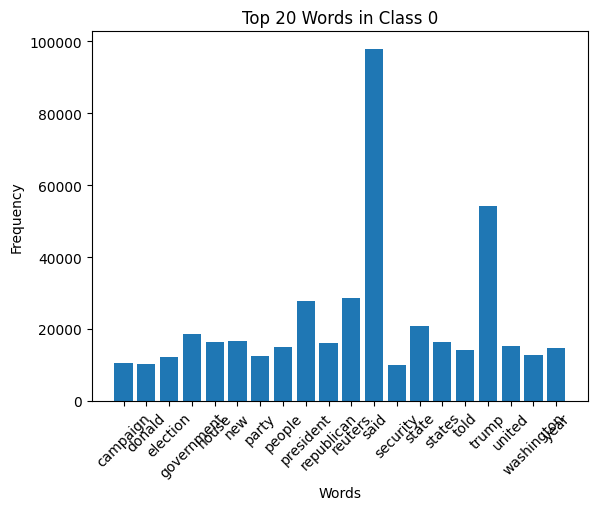

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Filter data for class 0
df_0 = df[df['Result'] == 0]

# Initialize vectorizer
vectorizer = CountVectorizer(stop_words='english', max_features=20)

# Fit and transform
X0 = vectorizer.fit_transform(df_0['text'])

# Get words and counts
words_0 = X0.toarray().sum(axis=0)
features_0 = vectorizer.get_feature_names_out()

# Plot
plt.figure()
plt.bar(features_0, words_0)
plt.xticks(rotation=45)
plt.title("Top 20 Words in Class 0")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

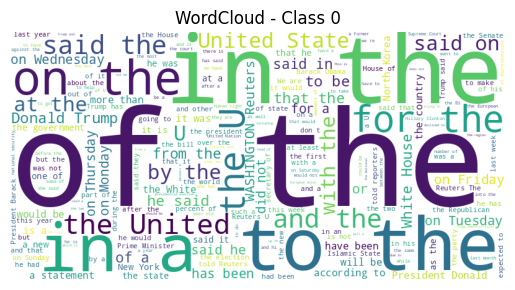

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter class 0
df_0 = df[df['Result'] == 0]

# Combine all text into one string
text_0 = " ".join(df_0['text'].astype(str))

# Generate WordCloud
wc_0 = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords='english'
).generate(text_0)

# Plot
plt.figure()
plt.imshow(wc_0)
plt.axis('off')
plt.title("WordCloud - Class 0")
plt.show()

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

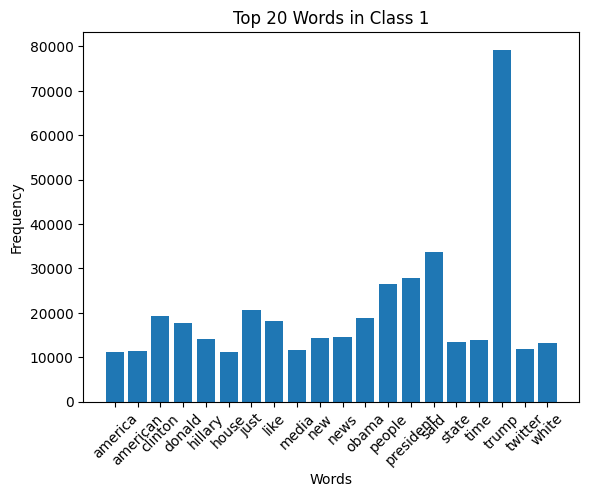

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Filter data for class 1
df_1 = df[df['Result'] == 1]

# Initialize vectorizer
vectorizer = CountVectorizer(stop_words='english', max_features=20)

# Fit and transform
X1 = vectorizer.fit_transform(df_1['text'])

# Get words and counts
words_1 = X1.toarray().sum(axis=0)
features_1 = vectorizer.get_feature_names_out()

# Plot
plt.figure()
plt.bar(features_1, words_1)
plt.xticks(rotation=45)
plt.title("Top 20 Words in Class 1")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

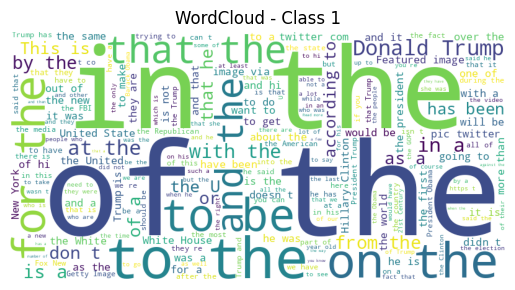

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter class 1
df_1 = df[df['Result'] == 1]

# Combine all text
text_1 = " ".join(df_1['text'].astype(str))

# Generate WordCloud
wc_1 = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords='english'
).generate(text_1)

# Plot
plt.figure()
plt.imshow(wc_1)
plt.axis('off')
plt.title("WordCloud - Class 1")
plt.show()

# **6. Textual Data Preprocessing**
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

### **Imports**

In [ ]:
!pip install contractions

import re
import nltk
import contractions

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

### **1. Expand Contraction**

In [ ]:
# Expand Contraction

In [ ]:
def expand_contractions(text):
    return contractions.fix(text)

dff['text'] = dff['text'].apply(expand_contractions)

### **2. Lower Casing**

In [ ]:
# Lower Casing

In [ ]:
dff['text'] = dff['text'].str.lower()

### **3. Removing Punctuations**

In [ ]:
# Remove Punctuations

In [ ]:
def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

dff['text'] = dff['text'].apply(remove_punctuation)

### **4. Removing URLs & Removing words and digits contain digits.**

In [ ]:
# Remove URLs & Remove words and digits contain digits

In [ ]:
def remove_urls_digits(text):
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'\w*\d\w*', '', text)        # remove words with digits
    return text

dff['text'] = dff['text'].apply(remove_urls_digits)

### **5. Removing Stopwords & Removing White spaces**

In [ ]:
# Remove Stopwords

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # <-- THIS fixes your error
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

dff['text'] = dff['text'].apply(remove_stopwords)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Remove White spaces

In [ ]:

# Remove extra spaces
dff['text'] = dff['text'].str.strip()

### **6. Rephrase Text**

In [ ]:
# Rephrase Text

In [ ]:
def clean_text(text):
    return re.sub(r'\s+', ' ', text)

dff['text'] = dff['text'].apply(clean_text)

### **7. Tokenization**

In [ ]:
# Tokenization

In [ ]:
dff['tokens'] = dff['text'].apply(word_tokenize)

### **8. Text Normalization**

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

dff['tokens'] = dff['tokens'].apply(lemmatize_text)

In [ ]:
dff['final_text'] = dff['tokens'].apply(lambda x: " ".join(x))

##### Which text normalization technique have you used and why?

Answer Here.

# **7. Data Splitting**

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

In [ ]:
X_text = dff['final_text']
y = dff['Result']

In [ ]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **8. TF-IDF Vectorization**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train = tfidf.fit_transform(X_train_text)   # fit only here
X_test = tfidf.transform(X_test_text)         # only transform

# ***9. ML Model Implementation***

# **ML Model-1 : Naive Bayes**

## **Fit the Algorithm**

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model


from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

## **Performance Of The Model**

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9427228996532051


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4242
           1       0.94      0.95      0.95      4697

    accuracy                           0.94      8939
   macro avg       0.94      0.94      0.94      8939
weighted avg       0.94      0.94      0.94      8939



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3973  269]
 [ 243 4454]]


## **Preprocessing The User's Input : To Be Predicted**

In [ ]:
def preprocess_input1(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [ ]:
def predict_news1(text):
    processed = preprocess_input1(text)

    vector = tfidf.transform([processed])
    # vector = selector.transform(vector)   # if you used feature selection

    pred = model.predict(vector)[0]

    return "Fake News ❌" if pred == 1 else "True News ✅"

## **Testing The User's Input Data**

In [ ]:
print(predict_news1("Scientists have confirmed that drinking warm lemon water every hour can completely cure cancer within two weeks. Hospitals worldwide are expected to adopt this natural treatment soon.."))

Fake News ❌


##**Explain the ML Model used and it's performance using Evaluation metric Score Chart.**

####**Naive Bayes Model Performance Summary**

The Multinomial Naive Bayes model was used for fake news classification due to its efficiency in handling textual data. The model achieved an accuracy of 94.27%, indicating strong overall performance.

From the classification report, both classes (True = 0 and Fake = 1) show balanced precision and recall (~0.94–0.95), resulting in a high F1-score of 0.94–0.95, which indicates a good balance between correctly identifying fake news and minimizing false predictions.

The confusion matrix shows that:

* 3973 True news instances were correctly classified

* 4454 Fake news instances were correctly classified

* 269 True news were incorrectly classified as fake (False Positives)

* 243 Fake news were missed (False Negatives)



Overall, the model demonstrates strong and balanced performance in detecting both real and fake news, making it a reliable baseline for the classification task.

# **ML Model - 2 Training Multiple Models**

### **Train Multiple Models**


In [ ]:
# ================================
# Train Multiple Models
# ================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Models
nb_model = MultinomialNB()
lr_model = LogisticRegression(max_iter=1000)
svm_model = LinearSVC()

# Train
nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

LinearSVC()

## **Performance Of Each Model**

In [ ]:
from sklearn.metrics import accuracy_score

# Predictions
nb_pred = nb_model.predict(X_test)
lr_pred = lr_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

# Accuracy
nb_acc = accuracy_score(y_test, nb_pred)
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)

print("\nNaive Bayes Accuracy:", nb_acc)
cm = confusion_matrix(y_test, nb_pred)
print("confusion_matrix : Naive Bayes\n",cm)

print("\nLogistic Regression Accuracy:", lr_acc)
cm = confusion_matrix(y_test, lr_pred)
print("\nconfusion_matrix : Logistic Regression\n",cm)

print("\nSVM Accuracy:", svm_acc)
cm = confusion_matrix(y_test, svm_pred)
print("confusion_matrix : SVM \n",cm)


Naive Bayes Accuracy: 0.9427228996532051
confusion_matrix : Naive Bayes
 [[3973  269]
 [ 243 4454]]

Logistic Regression Accuracy: 0.9859044635865309

confusion_matrix : Logistic Regression
 [[4188   54]
 [  72 4625]]

SVM Accuracy: 0.9941827944960286
confusion_matrix : SVM 
 [[4215   27]
 [  25 4672]]


## **Choosing The Best Model**

In [ ]:
models = {
    "Naive Bayes": nb_acc,
    "Logistic Regression": lr_acc,
    "SVM": svm_acc
}

best_model_name = max(models, key=models.get)

print("Best Model:", best_model_name)

Best Model: SVM


In [ ]:
# Assign best model
if best_model_name == "Naive Bayes":
    model = nb_model
elif best_model_name == "Logistic Regression":
    model = lr_model
else:
    model = svm_model

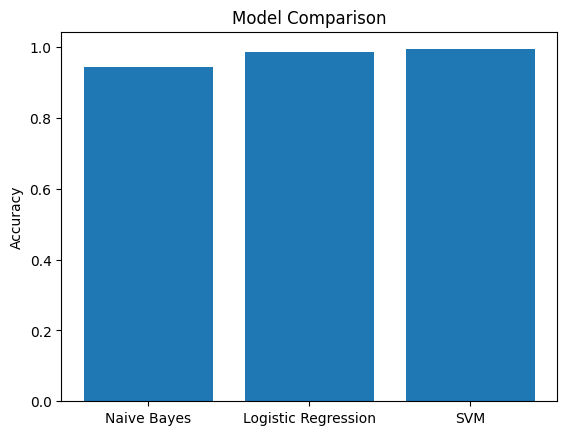

In [ ]:
import matplotlib.pyplot as plt

names = list(models.keys())
scores = list(models.values())

plt.bar(names, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

## **Preprocessing The User's Input : To Be Predicted**

In [ ]:
# def preprocess_input(text):
#     text = text.lower()
#     tokens = word_tokenize(text)
#     tokens = [lemmatizer.lemmatize(word) for word in tokens]
#     return " ".join(tokens)




import re
import contractions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def preprocess_input(text):

    # 1. Expand contractions
    text = contractions.fix(text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Remove URLs + words with digits
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\w*\d\w*', '', text)

    # 5. Remove stopwords
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]

    # 6. Remove extra spaces (handled later)

    # 7. Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    # 8. Join back
    text = " ".join(words)

    # 9. Clean extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def predict_news(text):
    processed = preprocess_input(text)

    vector = tfidf.transform([processed])

    try:
        vector = selector.transform(vector)
    except:
        pass

    pred = model.predict(vector)[0]
    print("Processed text:", processed)
    print("Non-zero features:", vector.nnz)

    return "Fake News ❌" if pred == 1 else "True News ✅"

## **Testing The Model**

In [ ]:
print(predict_news("A US Air Force transport aircraft with  written on its tail was seen approaching the Nur Khan base as Pakistan on Friday as Islamabad prepares to host peace talks between Washington and Tehran.Uncertainty shrouds the talks in Pakistan between the United States and Iran, with no announcement yet on the arrival of negotiators and both sides accusing the other of failing to properly implement a fragile ceasefire. While US President Donald Trump has voiced displeasure at Iran's handling of the Strait of Hormuz, which was meant to be reopened under the deal, Tehran has reacted angrily to Israeli attacks in Lebanon, insisting that it too falls under the agreement.  said Esmaeil Baqaei, Iran's foreign ministry spokesman.US Vice President JD Vance will lead the American team, joined by special envoy Steve Witkoff and presidential son-in-law Jared Kushner. Iran has not officially announced the composition of its delegation, per AFP. Tehran's ambassador to Pakistan on Thursday deleted a social media post saying an Iranian delegation would arrive in the country later that day."))

Processed text: u air force transport aircraft written tail seen approaching nur khan base pakistan friday islamabad prepares host peace talk washington tehranuncertainty shroud talk pakistan united state iran announcement yet arrival negotiator side accusing failing properly implement fragile ceasefire u president donald trump voiced displeasure iran handling strait hormuz meant reopened deal tehran reacted angrily israeli attack lebanon insisting fall agreement said esmaeil baqaei iran foreign ministry spokesmanus vice president jd vance lead american team joined special envoy steve witkoff presidential soninlaw jared kushner iran officially announced composition delegation per afp tehran ambassador pakistan thursday deleted social medium post saying iranian delegation would arrive country later day
Non-zero features: 80
True News ✅


In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

# ================================
# Prediction Function (All Models)
# ================================
# def predict_news11(text):
#     processed = preprocess_input(text)

#     vector = tfidf.transform([processed])

#     try:
#         vector = selector.transform(vector)
#     except:
#         pass

#     nb_pred = nb_model.predict(vector)[0]
#     lr_pred = lr_model.predict(vector)[0]
#     svm_pred = svm_model.predict(vector)[0]

#     def label(x):
#         return "Fake News ❌" if x == 1 else "True News ✅"

#     result = f"""SVM (Best Model): {label(svm_pred)}"""
# # Naive Bayes: {label(nb_pred)}
# # Logistic Regression: {label(lr_pred)}
#     return result

# ================================
# Gradio Interface
# ================================
interface = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(lines=5, placeholder="Enter news text here..."),
    outputs="text",
    title="📰 Fake News Detection System",
    description="Enter a news article to check whether it is Fake or True using multiple ML models."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://437f6d659a11e7ae1c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Scientists have confirmed that drinking warm lemon water every hour can completely cure cancer within two weeks. Hospitals worldwide are expected to adopt this natural treatment soon.

In [ ]:
# A US Air Force transport aircraft with "Charleston" written on its tail was seen approaching the Nur Khan base as Pakistan on Friday as Islamabad prepares to host peace talks between Washington and Tehran.Uncertainty shrouds the talks in Pakistan between the United States and Iran, with no announcement yet on the arrival of negotiators and both sides accusing the other of failing to properly implement a fragile ceasefire. While US President Donald Trump has voiced displeasure at Iran's handling of the Strait of Hormuz, which was meant to be reopened under the deal, Tehran has reacted angrily to Israeli attacks in Lebanon, insisting that it too falls under the agreement. "The holding of talks to end the war is dependent on the US adhering to its ceasefire commitments on all fronts, especially in Lebanon," said Esmaeil Baqaei, Iran's foreign ministry spokesman.US Vice President JD Vance will lead the American team, joined by special envoy Steve Witkoff and presidential son-in-law Jared Kushner. Iran has not officially announced the composition of its delegation, per AFP. Tehran's ambassador to Pakistan on Thursday deleted a social media post saying an Iranian delegation would arrive in the country later that day.

## **Explain the ML Model used and it's performance using Evaluation metric Score Chart.**

Three machine learning models were implemented: Naive Bayes, Logistic Regression, and Support Vector Machine (SVM).

* Naive Bayes achieved an accuracy of 94.27%, providing a good baseline performance with balanced predictions.

* Logistic Regression improved performance significantly with an accuracy of 98.59%, showing better generalization and fewer misclassifications.

* Support Vector Machine (SVM) performed the best with an accuracy of 99.41%, achieving the highest number of correct predictions and the least number of errors, as seen in its confusion matrix.

## **Evaluation**

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The evaluation metrics considered were Accuracy, Precision, Recall, and F1-score.

* Accuracy was used to measure overall correctness of the model.

* Precision was important to reduce false alarms (incorrectly labeling true news as fake).

* Recall was crucial to ensure that most fake news instances are correctly detected, minimizing the risk of missing harmful misinformation.

* F1-score was considered the most important metric as it provides a balance between precision and recall, ensuring reliable performance in real-world scenarios.

These metrics together help ensure that the model is both accurate and dependable, which is essential for minimizing the spread of fake news and maintaining trust.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**The Support Vector Machine (SVM)** model was selected as the final prediction model.

This decision was based on its highest **accuracy (99.41%)** and superior performance in the confusion matrix, where it showed the **least number of false positives and false negatives** compared to Naive Bayes and Logistic Regression.

SVM is particularly effective for high-dimensional data like TF-IDF features and is capable of finding optimal decision boundaries, making it highly suitable for text classification tasks.

Therefore, due to its excellent accuracy, robustness, and minimal misclassification, SVM was chosen as the final model for fake news detection.

# **10. Conclusion**

In this project, a Fake News Detection system was successfully developed using Natural Language Processing (NLP) and machine learning techniques. The textual data was preprocessed through steps such as tokenization and lemmatization, and meaningful features were extracted using the TF-IDF vectorization method.

Multiple machine learning models, including Naive Bayes, Logistic Regression, and Support Vector Machine (SVM), were implemented and evaluated using metrics like Accuracy, Precision, Recall, and F1-score. Among these, the SVM model achieved the best performance with the highest accuracy and the least number of misclassifications, making it the most suitable model for this task.

The results demonstrate that machine learning models can effectively classify news articles as real or fake with high accuracy. This system can help in reducing the spread of misinformation and can be further extended for real-time applications.

Overall, the project highlights the importance of NLP in solving real-world problems and provides a scalable approach for automated fake news detection.